In [1]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler

POPULARITY_WEIGHT = 1.5
RATING_WEIGHT = 1.5


WEIGHTED_RATING_PERCENTILE = 0.75

In [2]:
print("=" * 80)
print("STEP 1: LOADING DATA")
print("=" * 80)

df = pd.read_csv(r"C:\Users\raoro\OneDrive\Desktop\top10K-TMDB-movies.csv")
print(f"Raw shape: {df.shape}")
df.head()

STEP 1: LOADING DATA
Raw shape: (10000, 9)


,id,title,genre,original_language,overview,popularity,release_date,vote_average,vote_count
0,278,The Shawshank Redemption,"Drama,Crime",en,Framed in the 1940s for the double murder of h...,94.075,1994-09-23,8.7,21862
1,19404,Dilwale Dulhania Le Jayenge,"Comedy,Drama,Romance",hi,"Raj is a rich, carefree, happy-go-lucky second...",25.408,1995-10-19,8.7,3731
2,238,The Godfather,"Drama,Crime",en,"Spanning the years 1945 to 1955, a chronicle o...",90.585,1972-03-14,8.7,16280
3,424,Schindler's List,"Drama,History,War",en,The true story of how businessman Oskar Schind...,44.761,1993-12-15,8.6,12959
4,240,The Godfather: Part II,"Drama,Crime",en,In the continuing saga of the Corleone crime f...,57.749,1974-12-20,8.6,9811


In [3]:
print("\n" + "=" * 80)
print("STEP 2: DATA CLEANING")
print("=" * 80)

before = df.shape[0]
df = df.dropna(subset=["genre", "title"])
df = df.drop_duplicates(subset="title", keep="first")
print(f"Removed {before - df.shape[0]} rows with missing genre/title or duplicate titles")

df["overview"] = df["overview"].fillna("No overview available.")


df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

df["genre_list"] = df["genre"].apply(lambda g: [x.strip() for x in g.split(",") if x.strip()])


before = df.shape[0]
df = df[(df["vote_average"] > 0) & (df["popularity"] > 0)]
print(f"Removed {before - df.shape[0]} rows with zero rating/popularity")

df = df.reset_index(drop=True)
print(f"Cleaned shape: {df.shape}")


STEP 2: DATA CLEANING
Removed 342 rows with missing genre/title or duplicate titles
Removed 0 rows with zero rating/popularity
Cleaned shape: (9658, 11)



STEP 2.5: EXPLORATORY DATA ANALYSIS


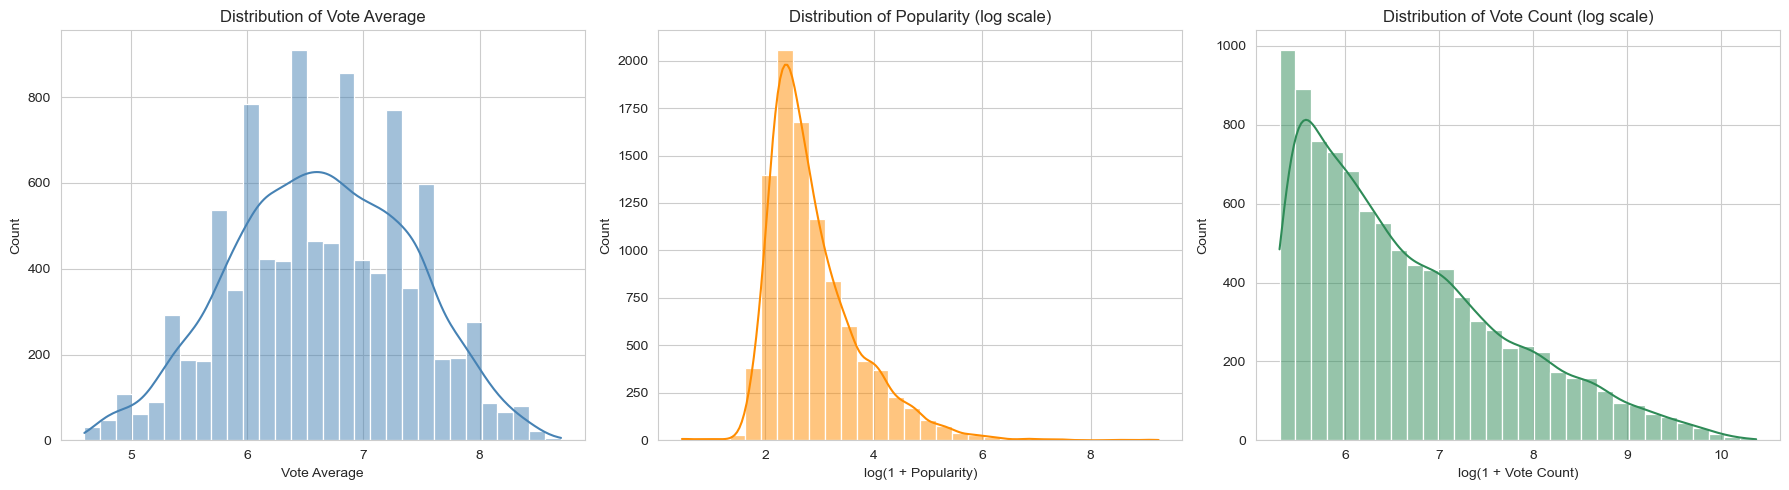

In [4]:
print("\n" + "=" * 80)
print("STEP 2.5: EXPLORATORY DATA ANALYSIS")
print("=" * 80)

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sns.histplot(df["vote_average"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Vote Average")
axes[0].set_xlabel("Vote Average")


sns.histplot(np.log1p(df["popularity"]), bins=30, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Popularity (log scale)")
axes[1].set_xlabel("log(1 + Popularity)")


sns.histplot(np.log1p(df["vote_count"]), bins=30, kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Distribution of Vote Count (log scale)")
axes[2].set_xlabel("log(1 + Vote Count)")

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150)
plt.show()


STEP 3: COMPUTING WEIGHTED RATING
Mean rating (C): 6.636   |   Min-votes threshold (m): 1454
                                        title  vote_average  vote_count  weighted_rating
                     The Shawshank Redemption           8.7       21862         8.571320
                                The Godfather           8.7       16280         8.530816
                              The Dark Knight           8.5       27925         8.407773
                             Schindler's List           8.6       12959         8.401919
                                 Pulp Fiction           8.5       23481         8.391336
                                 Forrest Gump           8.5       23009         8.389239
The Lord of the Rings: The Return of the King           8.5       19844         8.372779
                       The Godfather: Part II           8.6        9811         8.346564
                               The Green Mile           8.5       14162         8.326488
                

C:\Users\raoro\AppData\Local\Temp\ipykernel_33156\940864685.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="weighted_rating", y="title", data=top10, palette="mako")


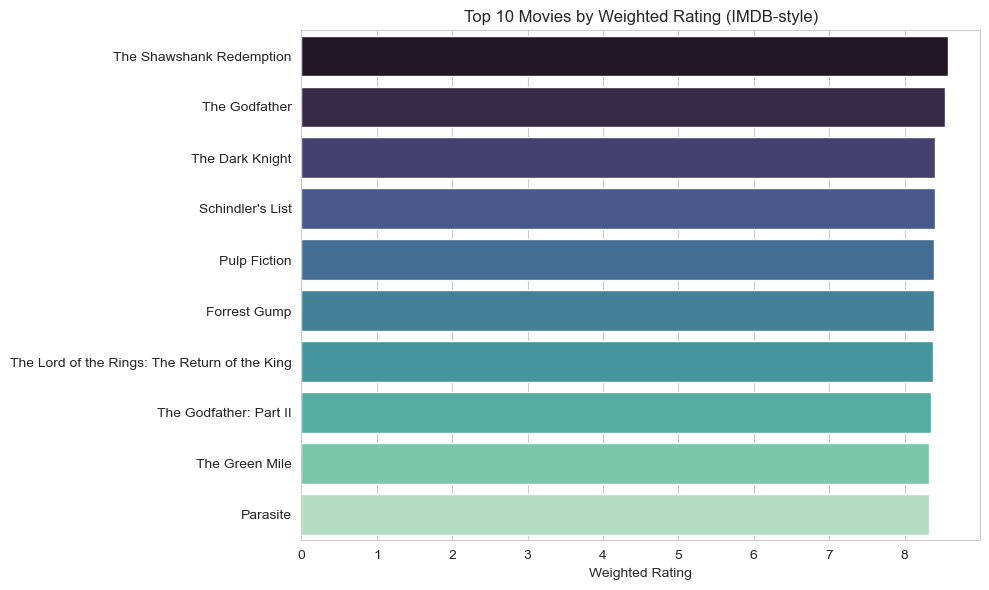

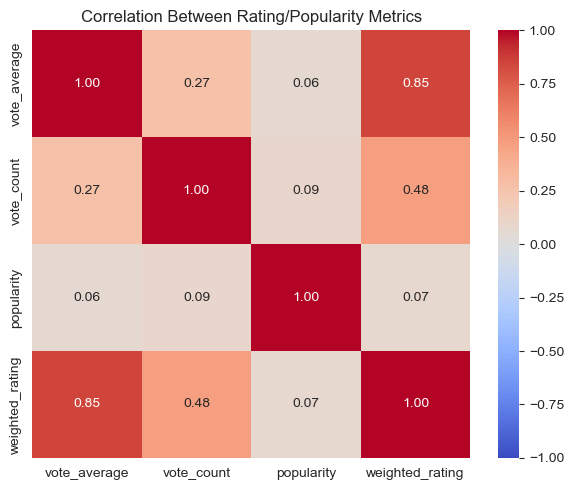

In [5]:
print("\n" + "=" * 80)
print("STEP 3: COMPUTING WEIGHTED RATING")
print("=" * 80)

C = df["vote_average"].mean()
m = df["vote_count"].quantile(WEIGHTED_RATING_PERCENTILE)
print(f"Mean rating (C): {C:.3f}   |   Min-votes threshold (m): {m:.0f}")


def weighted_rating(row, m=m, C=C):
    v = row["vote_count"]
    R = row["vote_average"]
    return (v / (v + m) * R) + (m / (v + m) * C)


df["weighted_rating"] = df.apply(weighted_rating, axis=1)
print(df[["title", "vote_average", "vote_count", "weighted_rating"]].sort_values(
    "weighted_rating", ascending=False).head(10).to_string(index=False))

top10 = df.sort_values("weighted_rating", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="weighted_rating", y="title", data=top10, palette="mako")
plt.title("Top 10 Movies by Weighted Rating (IMDB-style)")
plt.xlabel("Weighted Rating")
plt.ylabel("")
plt.tight_layout()
plt.savefig("eda_top10_weighted.png", dpi=150)
plt.show()

corr_cols = ["vote_average", "vote_count", "popularity", "weighted_rating"]
corr = df[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Rating/Popularity Metrics")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150)
plt.show()


STEP 4: BUILDING FEATURE MATRIX
Genres found (18): ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
Feature matrix shape: (9658, 20)


C:\Users\raoro\AppData\Local\Temp\ipykernel_33156\2726739686.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")


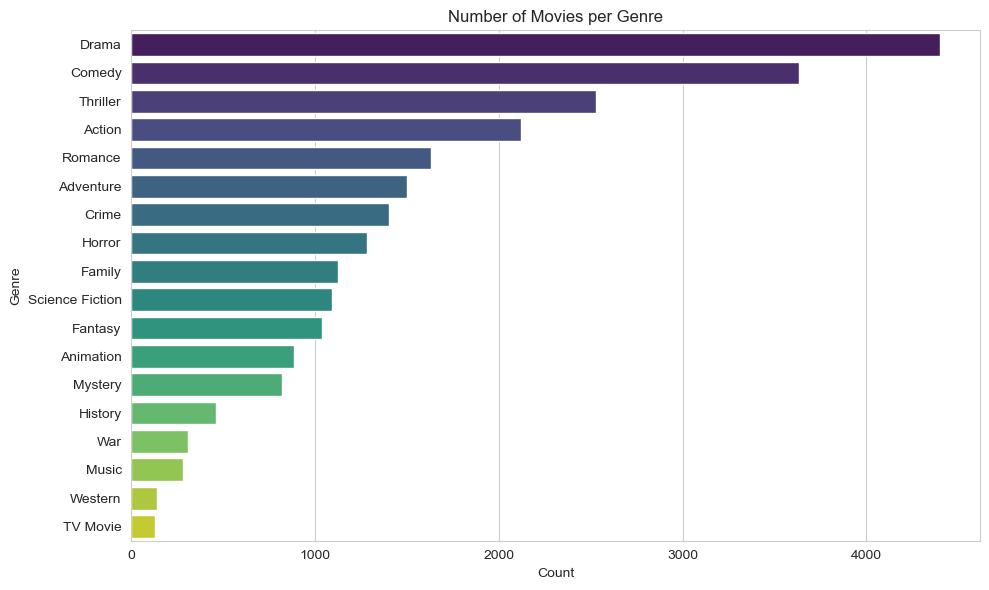

Most common genre: Drama (4398 movies)
Least common genre: TV Movie (129 movies)


In [6]:
print("\n" + "=" * 80)
print("STEP 4: BUILDING FEATURE MATRIX")
print("=" * 80)


mlb = MultiLabelBinarizer()
genre_features = mlb.fit_transform(df["genre_list"])
genre_feature_names = list(mlb.classes_)
print(f"Genres found ({len(genre_feature_names)}): {genre_feature_names}")


scaler = MinMaxScaler()
scaled_num = scaler.fit_transform(df[["popularity", "vote_average"]])
scaled_num = scaled_num * np.array([POPULARITY_WEIGHT, RATING_WEIGHT])


X = np.hstack([genre_features, scaled_num])
feature_names = genre_feature_names + ["popularity_scaled", "vote_average_scaled"]
print(f"Feature matrix shape: {X.shape}")

genre_counts = pd.Series(
    [g for genre_list in df["genre_list"] for g in genre_list]
).value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")
plt.title("Number of Movies per Genre")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("eda_genre_counts.png", dpi=150)
plt.show()

print(f"Most common genre: {genre_counts.idxmax()} ({genre_counts.max()} movies)")
print(f"Least common genre: {genre_counts.idxmin()} ({genre_counts.min()} movies)")


STEP 5: TRAINING NEAREST NEIGHBORS MODEL and VISUALIZING THE FEATURE SPACE (PCA)
Model trained.


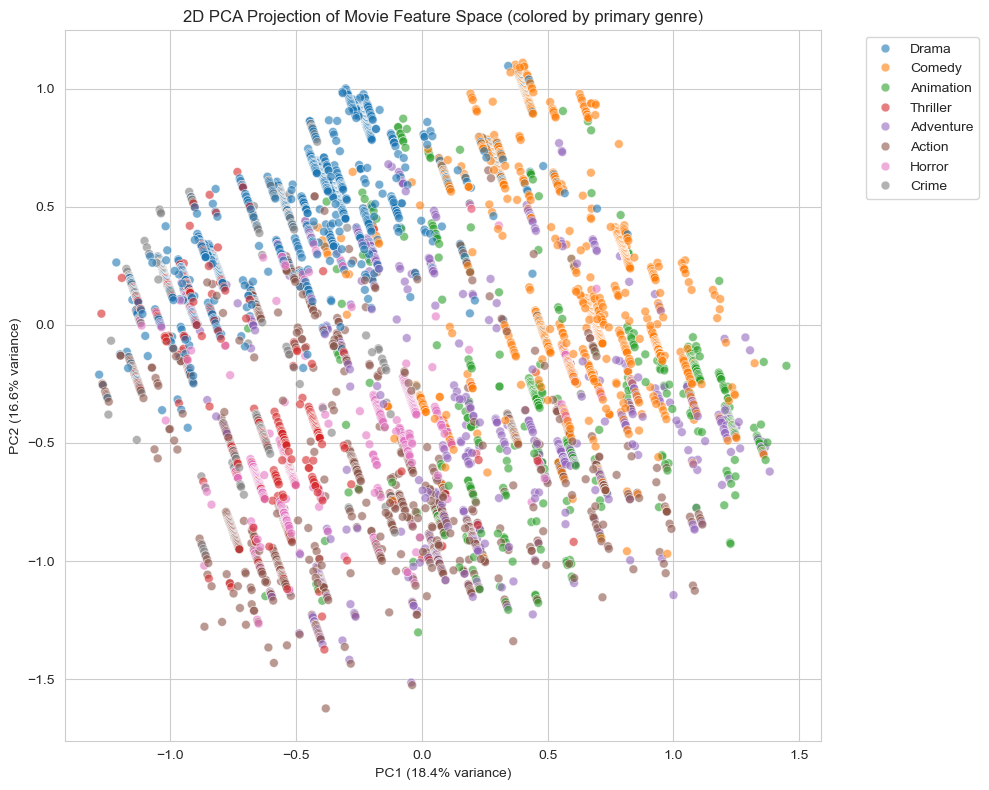

Explained variance by 2 components: 35.1%


In [10]:
print("\n" + "=" * 80)
print("STEP 5: TRAINING NEAREST NEIGHBORS MODEL and VISUALIZING THE FEATURE SPACE (PCA)")
print("=" * 80)

nn_model = NearestNeighbors(n_neighbors=50, metric="cosine", algorithm="brute")
nn_model.fit(X)
print("Model trained.")

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

primary_genre = df["genre_list"].apply(lambda g: g[0] if g else "Unknown")

plt.figure(figsize=(10, 8))
top_genres = primary_genre.value_counts().head(8).index
mask = primary_genre.isin(top_genres)

sns.scatterplot(
    x=X_2d[mask, 0], y=X_2d[mask, 1],
    hue=primary_genre[mask], palette="tab10", alpha=0.6, s=40
)
plt.title("2D PCA Projection of Movie Feature Space (colored by primary genre)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("eda_pca_projection.png", dpi=150)
plt.show()

print(f"Explained variance by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [8]:
print("\n" + "=" * 80)
print("STEP 6: RECOMMENDATION FUNCTION")
print("=" * 80)


def recommend_by_genre(genre, top_n=10, min_vote_count=100):
    """
    Recommend movies in the given genre, ranked by rating & popularity,
    using the trained NearestNeighbors ML model.

    Parameters
    ----------
    genre : str
        A genre the user selects, e.g. "Action". Must be one of:
        {genres}
    top_n : int
        How many movies to return.
    min_vote_count : int
        Ignore movies with fewer votes than this (avoids obscure/unreliable
        entries sneaking into the results).
    """
    if genre not in genre_feature_names:
        print(f"'{genre}' not found. Available genres: {genre_feature_names}")
        return pd.DataFrame()
    query = np.zeros(X.shape[1])
    genre_idx = genre_feature_names.index(genre)
    query[genre_idx] = 1
    query[-2] = POPULARITY_WEIGHT
    query[-1] = RATING_WEIGHT
    query = query.reshape(1, -1)

    distances, indices = nn_model.kneighbors(query, n_neighbors=min(200, len(df)))

    candidates = df.iloc[indices[0]].copy()
    candidates["distance"] = distances[0] 
    candidates = candidates[
        candidates["genre_list"].apply(lambda g: genre in g)
        & (candidates["vote_count"] >= min_vote_count)
    ]

    candidates = candidates.sort_values(
        ["weighted_rating", "popularity"], ascending=[False, False]
    )

    result = candidates[[
        "title", "genre", "release_year", "vote_average",
        "vote_count", "popularity", "weighted_rating", "overview",
    ]].head(top_n).reset_index(drop=True)

    return result


recommend_by_genre.__doc__ = recommend_by_genre.__doc__.format(genres=genre_feature_names)
print("Step 6 initialized")


STEP 6: RECOMMENDATION FUNCTION
Step 6 initialized


In [9]:
print("\n" + "=" * 80)
print("STEP 7: EXAMPLE RECOMMENDATIONS")
print("=" * 80)

for demo_genre in ["Action", "Comedy", "Animation"]:
    print(f"\n--- Top picks for genre: {demo_genre} ---")
    picks = recommend_by_genre(demo_genre, top_n=5)
    print(picks[["title", "release_year", "vote_average", "popularity", "weighted_rating"]].to_string(index=False))


print("\n" + "=" * 80)
print("STEP 8: SAVING BUNDLE FOR STREAMLIT")
print("=" * 80)

bundle = {
    "df": df,
    "nn_model": nn_model,
    "scaler": scaler,
    "mlb": mlb,
    "genre_feature_names": genre_feature_names,
    "feature_names": feature_names,
    "popularity_weight": POPULARITY_WEIGHT,
    "rating_weight": RATING_WEIGHT,
}

pickle_file_path = r"C:\Users\raoro\OneDrive\Desktop\movies1.pkl"

with open(pickle_file_path, 'wb')as f:
    pickle.dump(bundle, f)


print(f"Available genres for the Streamlit dropdown: {genre_feature_names}")


STEP 7: EXAMPLE RECOMMENDATIONS

--- Top picks for genre: Action ---
                                            title  release_year  vote_average  popularity  weighted_rating
    The Lord of the Rings: The Return of the King          2003           8.5     134.707         8.372779
                                        Inception          2010           8.4     111.757         8.323162
The Lord of the Rings: The Fellowship of the Ring          2001           8.4     168.448         8.286847
            The Lord of the Rings: The Two Towers          2002           8.4     162.716         8.270653
                          The Empire Strikes Back          1980           8.4      28.323         8.238099

--- Top picks for genre: Comedy ---
                   title  release_year  vote_average  popularity  weighted_rating
           Life of Brian          1979           7.8      17.840         7.462145
      Young Frankenstein          1974           7.9      14.001         7.446773
     